In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.pipeline import Pipeline

In [48]:
X_train = pd.read_csv('../Datasets/processed/X_train.csv')
X_val   = pd.read_csv('../Datasets/processed/X_val.csv')
X_test  = pd.read_csv('../Datasets/processed/X_test.csv')
y_train = pd.read_csv('../Datasets/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../Datasets/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../Datasets/processed/y_test.csv').squeeze()

scaler = RobustScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print(X_train.describe().round(2))

       cement    slag  fly_ash   water  superplasticizer  coarse_agg  \
count  603.00  603.00   603.00  603.00            603.00      603.00   
mean     0.05    0.37     0.45   -0.13             -0.01        0.04   
std      0.68    0.64     0.54    0.82              0.60        0.80   
min     -1.14   -0.14     0.00   -2.42             -0.60       -1.72   
25%     -0.51   -0.14     0.00   -0.72             -0.60       -0.37   
50%      0.00    0.00     0.00    0.00              0.00        0.00   
75%      0.49    0.86     1.00    0.28              0.40        0.63   
max      1.71    2.55     1.69    1.94              2.62        1.72   

       fine_agg     age  
count    603.00  603.00  
mean      -0.06    0.44  
std        0.81    1.45  
min       -1.83   -0.59  
25%       -0.51   -0.38  
50%        0.00    0.00  
75%        0.49    0.62  
max        2.09    7.41  


Algorithm testing using single cross validation set


Best k: 3, Val RMSE: 7.9387


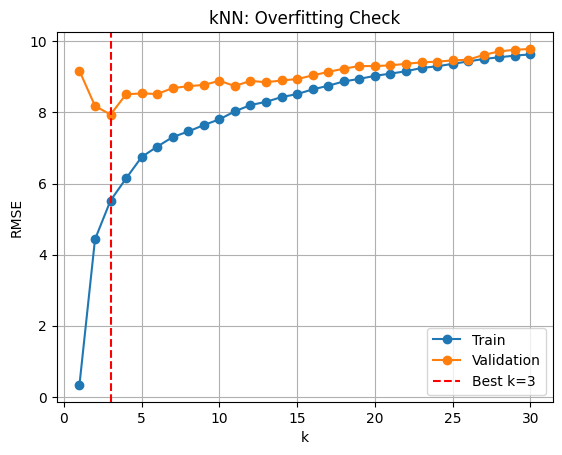

In [49]:

train_rmse_list = []
val_rmse_list = []
k_range = range(1, 31)

for k in k_range:
    knn_cv = KNeighborsRegressor(n_neighbors=k)
    knn_cv.fit(X_train, y_train)
    
    train_rmse_list.append(np.sqrt(mean_squared_error(y_train, knn_cv.predict(X_train))))
    val_rmse_list.append(np.sqrt(mean_squared_error(y_val, knn_cv.predict(X_val))))


best_k = k_range[np.argmin(val_rmse_list)]
print(f"Best k: {best_k}, Val RMSE: {min(val_rmse_list):.4f}")

plt.plot(k_range, train_rmse_list, label='Train', marker='o')
plt.plot(k_range, val_rmse_list,   label='Validation', marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('kNN: Overfitting Check')
plt.legend()
plt.grid(True)
plt.show()




In [50]:
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
y_pred_train = knn.predict(X_train)
y_pred = knn.predict(X_test)

print("RMSE training:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R² training:", r2_score(y_train, y_pred_train))

print("RMSE testing:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² testing:", r2_score(y_test, y_pred))

RMSE training: 5.522301655568156
R² testing: 0.8830576797715924
RMSE testing: 8.98614193587343
R² testing: 0.7414139219425143


# kNN with k-folds validation

In [52]:
df = pd.read_csv(r"../Datasets/uci_concrete_data.csv")

df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()


df_clean.columns = [
    "cement", "slag", "fly_ash", "water",
    "superplasticizer", "coarse_agg",
    "fine_agg", "age", "strength"
]

X = df_clean.drop("strength", axis=1)
y = df_clean["strength"]


X_train_kf, X_test_kf, y_train_kf, y_test_kf = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Best k (K-Fold): 3, RMSE validation: 8.0434


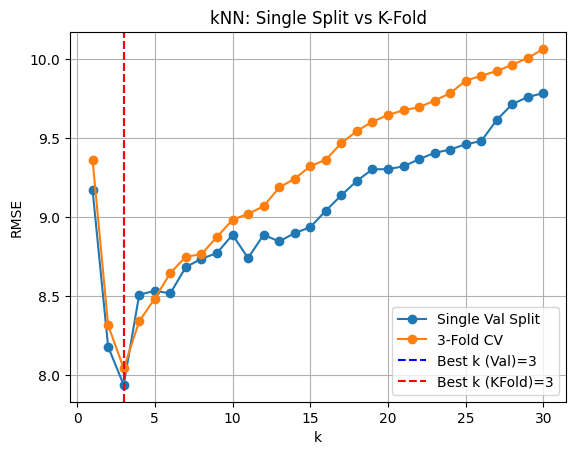

In [53]:
k_range = range(1,31)
kfold_rmse_list = []
kfold_std_list = []


for k in k_range:
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k))
    ])
    scores = cross_val_score(pipeline, X_train_kf, y_train_kf,
                             cv=3, scoring='neg_root_mean_squared_error')
    kfold_rmse_list.append(-scores.mean())
    kfold_std_list.append(scores.std())

best_k_kfold = k_range[np.argmin(kfold_rmse_list)]
print(f"Best k (K-Fold): {best_k_kfold}, RMSE validation: {min(kfold_rmse_list):.4f}")

plt.plot(k_range, val_rmse_list,    label='Single Val Split', marker='o')
plt.plot(k_range, kfold_rmse_list,  label='3-Fold CV',        marker='o')
plt.axvline(x=best_k,       color='blue', linestyle='--', label=f'Best k (Val)={best_k}')
plt.axvline(x=best_k_kfold, color='red',  linestyle='--', label=f'Best k (KFold)={best_k_kfold}')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('kNN: Single Split vs K-Fold')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
final_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_k_kfold))
])
final_pipeline.fit(X_train_kf, y_train_kf)

y_pred_kfold = final_pipeline.predict(X_test_kf)

# Training RMSE
y_pred_train = final_pipeline.predict(X_train_kf)
print("Training RMSE:", np.sqrt(mean_squared_error(y_train_kf, y_pred_train)))
print("Training R²  :", r2_score(y_train_kf, y_pred_train))

# Testing RMSE
y_pred_kfold = final_pipeline.predict(X_test_kf)
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test_kf, y_pred_kfold)))
print("Testing R²  :", r2_score(y_test_kf, y_pred_kfold))

Training RMSE: 5.176062242693093
Training R²  : 0.894071610395507
Testing RMSE: 8.948846037682285
Testing R²  : 0.7435559282818462
